In [1]:
# 파이프라인 이란
    # 데이터 전처리, 특성 추출, 모델학습을 하나의 흐름으로 연결
# 사용이유
    # 코드 간결화 : 여러단계를 하나로 묶어 관리 
    # 재현성 보장 : 전체 프로세스를 일관되게 실행
    # 데이터 누수 방지 : 교차 검증시 각 fold에서 독립적으로 전처리
    # 하이퍼 파라미터 튜닝 용이 : 전체 파이프라인에 대해서 그리드서치 적용
# 파이프라인 구성요소
    # 변환기
        # 데이터를 변환하는 객체 
        # fit(): 데이터에서 파라미터를 학습
        # standardScaler, PCA, MinMaxScaler, ...
    # 추정기
        # 머신러닝 모델
        # fit() : 데이터로 모델을 학습
        # predict() : 예측, 수행
        # RandomForest, SVM, ... 


##### 데이터 : 위스콘시 유방암 데이터 / 대표적인 이진분류 데이터
- 클래스 2 (양성, 악성)
- 특성 :  10개

| 그룹 | Feature 이름          | 의미                                |
|:----:|:----------------------|:------------------------------------|
| 1    | `radius`              | 세포 핵의 반지름 평균 (centroid와 경계 사이 거리) |
| 2    | `texture`             | 회색조 값의 표준편차 (질감)                  |
| 3    | `perimeter`           | 세포 핵의 둘레 길이                       |
| 4    | `area`                | 세포 핵의 면적                          |
| 5    | `smoothness`          | 반지름의 국소적 변화 (핵 경계의 매끄러움)          |
| 6    | `compactness`         | 둘레² / 면적 - 1.0 (핵의 조밀도)           |
| 7    | `concavity`           | 오목한 부분의 심도 (함몰 정도)                |
| 8    | `concave points`      | 오목한 부분의 개수                        |
| 9    | `symmetry`            | 대칭성                               |
| 10   | `fractal_dimension`   | 경계의 복잡도 (프랙탈 차원 근사값)              |


In [2]:
# 파이프라인 구성
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression   #각 클래스에 대한 확률값을 출력하고 이후 이 확률값이 큰 클래스가 선택 ==> 분류모델
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('claffier', LogisticRegression())
])

In [3]:
# 파이프라인 실행과정
#     pipe.fit(x_train, y_train)
#     StandarScaler가 x_train 에 fit --> 평균과 표준편차 계산
#     x_train을 표준화 x_scaled
#     PCA가 x_scaled에 대해서 fit --> 주성분을 계산
#     x_scaled를 x_pca로 변환
#     LogisticRegression이 x_pca를 fit

In [4]:
# 데이터 누수 방지
# - 잘못된 예
#     - 전체 데이터를 먼저 스케일링
#       X_scaled = scaler.fit_transform(X)
#       X_train, X_test = train_test_fit (X_scaled)
#       model.fit(X_train, y_train)
#       문제 --> 테스트 데이터 정보가 스케일에 사용
# - 올바른 예
#     - 학습 데이터만 스케일링
#       X_train, X_test = train_test_fit (X)
#       X_train_scaled = scaler.fit_transform(X_train)
#       X_test_scaled = scaler.transform(X_test)  #fit 없이 transform만!!
#       model.fit(X_train_scaled, y_train)

In [5]:
# 파이프라인 사용 (best)
# pipe.fit(x_train, y_train)   #학습데이터만 fit
# pipe.predict(x_test)  #테스트 데이터는 transform만 진행하게 됨.

In [ ]:
# 홀드아웃 : 데이터를 학습 세트, 테스트 세트 한번만!! 분할
    # 전체데이터 : 100%
        # 학습 70~80
        # 테스트 20~30
    # 장점:
        # 빠르다
        # 대용량 데이터에 적합
    # 단점:
        # 데이터 분할에 따라서 성능이 크게 달라질 수 있음
        # 작은 데이터셋에서는 불안
        # 일부 데이터만 학습에 사용
    # 언제 사용:
        # 데이터가 충분히 많을 때 (수많개 이상)
        # 빠르게 평가할 때


# 교차 검증 : 머신러닝이 모델을 얼마나 잘 학습했는지 평가하는 방법
# k겹 교차 : 홀드아웃보다 더 발전된 평가 방법 / 홀드아웃이 기본
    # 홀드아웃을 여러번 반복해서 평균을 내는 방법

#### k 겹 교차검증 (k-fold cross-validation)
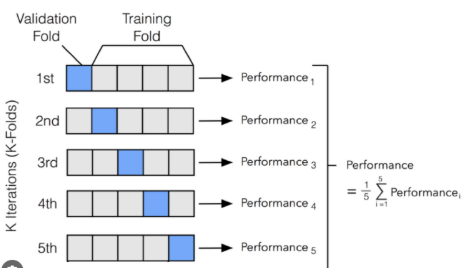



In [ ]:
# k-fold 종류
    # 일반 k-fold : 여러번 나눠서 평균냄
    # 층화 stratified k-fold : K-Fold + 클래스 비율 유지
        # Stratified = “계층화된”
        # 즉, 각 조각(fold) 안에서도 클래스(예: 정상/암) 비율을 유지함
        # 클래스 불균형(예: 암이 10%, 정상 90%)이 있을 때 특히 중요해요.
        # 💬 일반 K-Fold는 섞을 때 한쪽 클래스가 너무 적을 수도 있음
        # → Stratified는 이런 문제를 막음

In [8]:
# 학습곡선과 검증곡선 (시각화)
    # 학습 데이터 크기에 따른 모델 성능을 시각화

In [9]:
# 그리드 서치를 사용한 머신러닝 모델 세부 튜닝
# 하이퍼 파라미터
    # 파라미터 : 학습의 결과물 (학습으로 찾은 값) 
                # 선형회귀 계수, 신경망의 가중치, ...
    # 하이퍼 파라미터 : 사람이 설정
                # 학습률, 정규화, 트리의 깊이, ... 

# 그리드 서치 : 모든 가능한 조합으로 체계적으로 시도
# param_grid = {
#       'max_depth' : [3,5, ],
#        ..........
# }

# 랜덤 그리드서치 : 모든 가능한 조합을 랜덤하게. ==> 좀 더 효율적임
    # 더 넓은 영역을 탐색할 때 사용 --> 파라미터 조합의 경우의 수
    # 시간제약이 있을 때 

# 언제 사용?
    # 그리드서치 : 하이퍼 파라미터가 2~3개 (param_grid에 2~3개 항목 (ex. max_depth, ..)기재) 
    # 랜덤 그리드서치 : 하이퍼 파라미터가 4개 이상 

# 예시
# A,B 그리드 서치 3개 /  A: 3개의 고유값 / B: 3개의 고유값 을 가진다고 가정할 때
# 랜덤그리드서치는 9번을 시도함 --> 서로 다른 최대 9개의 값으로 시도 --> 중요한 파라미터에 더 많은 시도를 할 수 있음.
# ===> 그리드서치보다 랜덤 그리드서치가 최적으로 잘 찾는 경우가 더 많음


In [10]:
# 필요한 라이브러리
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
        train_test_split, cross_val_score, StratifiedKFold, learning_curve, 
        validation_curve, GridSearchCV, RandomizedSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from scipy.stats import randint, uniform
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

In [11]:
# section 1: 위스콘신 유방암 데이터셋 로드 및 탐색
def section1_load_data():
    # 데이터셋 구조 이해
    # 특성과 타겟의 관계 파악
    # 클래스 분포 확인
    print ('Section 1 : 위스콘신 유방암 데이터셋 ')

    # 데이터셋 로드
    data = load_breast_cancer()
    X, y = data.data, data.target
    print ('데이터셋 기본정보')
    print (f'샘플 수 : { X.shape[0] }')
    print (f'특성 수 : { X.shape[1] }')
    print (f'클래스 : {data.target_names}')
    # 클래스 분포
    unique, counts = np.unique(y, return_counts=True)  # return_counts => value_counts 같은 의미
    print ('클래스분포')
    for label, count in zip(unique, counts):
        class_name = data.target_names[label]
        percentage = count / len(y)*100
        print (f' {class_name} : {count}개 ({percentage:.1f}%)')
    # 특성통계
    print('특성 통계 (처음 5개 특성)')
    df_lists = []
    for i in range(5):
        index_name = data.feature_names[i]
        stats = {
                'mean': X[:,i].mean(),
                    'std':X[:,i].std(),
                    'min':X[:,i].min(),
                    'max':X[:,i].max()
        }    
        df_lists.append(pd.DataFrame(stats,index = [index_name]))
    print(pd.concat(df_lists))
    return X, y, data

In [12]:
X,y,data = section1_load_data()

# 클래스분포 : 하기정도 편차는 머신러닝에서 불균형으로 보진 않음.
#  malignant : 212개 (37.3%)
#  benign : 357개 (62.7%)

Section 1 : 위스콘신 유방암 데이터셋 
데이터셋 기본정보
샘플 수 : 569
특성 수 : 30
클래스 : ['malignant' 'benign']
클래스분포
 malignant : 212개 (37.3%)
 benign : 357개 (62.7%)
특성 통계 (처음 5개 특성)
                       mean         std        min        max
mean radius       14.127292    3.520951    6.98100    28.1100
mean texture      19.289649    4.297255    9.71000    39.2800
mean perimeter    91.969033   24.277619   43.79000   188.5000
mean area        654.889104  351.604754  143.50000  2501.0000
mean smoothness    0.096360    0.014052    0.05263     0.1634


In [ ]:
# session 2 파이프라인 기본 사용법

def section2_basic_pipeline(X,y):
    
    # Pipeline 객체 생성
    # 표준화 + 모델 학습을 한번에 수행
    # 파이프라인 장점을 이해
    
    # 데이터 분할
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)
    # 수동방식
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    Ir = LogisticRegression(random_state=42, max_iter=1000)  
                            # max_iter는 "최대 반복 횟수 (maximum iterations)" 
                            # 모델이 학습할 때, 수학적으로 해(가중치)를 찾기 위해 반복 계산하는 횟수의 한계
    Ir.fit(X_train_scaled, y_train)
    manual_score = Ir.score(X_test_scaled, y_test)
        # score  : 분류모델 - accuracy(정확도) / 예측모델 - 결정계수
        # score 함수 자체가 predict를 계산해줌. 
    print(f'학습세트 크기 : {X_train.shape[0]}')
    print(f'학습세트 크기 : {X_test.shape[0]}')
    print(f'테스트 정확도 : {manual_score:.2f}')



    #############################
    # 파이프라인 이용
    print ('파이프라인', '='*20)
    pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clssifier', LogisticRegression(random_state=42, max_iter=10000))
    ])
    pipe.fit(X_train, y_train)  #pipe는 scalar 을 알아서 해줌 
    pipeline_score = pipe.score(X_test, y_test)
    
    # 파이프라인 구조
    print ('파이프라인 구조')
    for name, step in pipe.steps : 
        print (f'{name} : {step.__class__.__name__}')

    print (f'테스트 정확도 : {pipeline_score:.4f}')
    print (f'수동방식과 동일한 결과 : {np.isclose(manual_score, pipeline_score)}')

In [14]:
section2_basic_pipeline(X,y)

학습세트 크기 : 398
학습세트 크기 : 171
테스트 정확도 : 0.99
파이프라인 ====================
파이프라인 구조
scaler : StandardScaler
clssifier : LogisticRegression
테스트 정확도 : 0.9883
수동방식과 동일한 결과 : True


In [ ]:
# 교차 검증 비교 (홀드아웃 vs k-fold)
def section3_cross_validation (X,y):
    
    # 홀드아웃의 한계
    # k-fold 교차검증의 장점
    # stratified k-fold 의 중요성

        pipe=Pipeline([
            ('scaler', StandardScaler()),
            ('clssifier', LogisticRegression(random_state=42, max_iter=10000))
         ])


    # 여러번 반복해서 불안정성 확인 holdout
        holdout_scores = []
        for i in range(10) :
                X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=i, stratify=y)
                pipe.fit(X_train, y_train)
                holdout_score=pipe.score(X_test, y_test)
                holdout_scores.append(holdout_score)
                # 처음 3개만 출력
                if i < 3:
                  print(f' {i+1} : {holdout_score:.4f}')
        print('=====================')
        print(f'홀드아웃 평균 : {np.mean(holdout_scores):4f} 표준편차 :{np.std(holdout_scores):.4f}')
                                                                # 표준편차가 클수록 결과가 불안정하다는 뜻
        print(f'min : {np.min(holdout_scores)} max : {np.max(holdout_scores)}' )
    
        # 5-fold 교차검증
        cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
                                # 데이터를 5조각으로 나눠서 5번 반복 학습
                                # 각 조각을 한 번씩 테스트용으로 써보고, 정확도 평균 계산
                                # cv=5 → 5번 나눈다는 뜻
        print('각 fold의 점수')
        for i, score in enumerate (cv_scores,1):
                print(f' fold {i} : {score:.4f}')
        print (f'5-fold 교차검증 평균 : {np.mean(cv_scores):.4f} 표준편차 : {np.std(cv_scores):.4f}')
                                                        # 표준편차가 클수록 결과가 불안정하다는 뜻
        print('=====================')
        
        
        # stratified k-fold : K-Fold + 클래스 비율 유지
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        stratified_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
        print('각 fold의 점수')
        for i, score in enumerate (stratified_scores,1):
                print(f' fold {i} : {score:.4f}')
        print (f'stratified 교차검증 평균 : {np.mean(stratified_scores):.4f} 표준편차 : {np.std(stratified_scores):.4f}')

        # 각 fold의 클래스 분포 확인
        for i, (train_index, test_index) in enumerate(skf.split(X,y), 1):
                                        # split(X,y) 클래스를 분명하게 하기위해?? index를...??
                y_fold = y[test_index]
                unique, counts = np.unique(y_fold, return_counts=True)
                ratio = counts[1]/ len(y_fold)*100
                print (f' fold {i} : 악성 {ratio:.1f}%')
        print("결론")
        print(f'holdout : 분할에 따라 성능차이가 큼 : {np.std(holdout_scores): .4f}')
        print(f'k-fold : 더 안정적인 추정 : {np.std(cv_scores): .4f}')
        print(f'stratified_scores : 클래스 비율 유지로 더 신뢰성 있음')

In [ ]:
section3_cross_validation (X,y)

# 모델에 대한 평가는 층화 교차 검증이 더 정확함
# stratified 교차검증 평균 : 0.9737 표준편차 : 0.0166

 1 : 0.9591
 2 : 0.9591
 3 : 0.9649
홀드아웃 평균 : 0.971930 표준편차 :0.0101
min : 0.9590643274853801 max : 0.9883040935672515
각 fold의 점수
 fold 1 : 0.9825
 fold 2 : 0.9825
 fold 3 : 0.9737
 fold 4 : 0.9737
 fold 5 : 0.9912
5-fold 교차검증 평균 : 0.9807 표준편차 : 0.0065
각 fold의 점수
 fold 1 : 0.9737
 fold 2 : 0.9474
 fold 3 : 0.9649
 fold 4 : 0.9912
 fold 5 : 0.9912
stratified 교차검증 평균 : 0.9737 표준편차 : 0.0166
 fold 1 : 악성 62.3%
 fold 2 : 악성 62.3%
 fold 3 : 악성 63.2%
 fold 4 : 악성 63.2%
 fold 5 : 악성 62.8%
결론
holdout : 분할에 따라 성능차이가 큼 :  0.0101
k-fold : 더 안정적인 추정 :  0.0065
stratified_scores : 클래스 비율 유지로 더 신뢰성 있음


In [17]:
# section 4 : 학습 곡선으로 편항-분산 분석
def section4_learning_curves(X,y):
    
    # 학습곡선
    # 과소적합 / 과대적합 판단
    # 데이터 추가 필요성 판단

    print('다양한 모델의 학습곡선 비교')
    models = [
        ('과소적합 예시\n (단순 모델)',
          Pipeline([ ('scaler', StandardScaler()), ('clf', LogisticRegression(C=0.01, max_iter = 1000)) ])),
                                                             # C는 규제 강도

        ('적절한 적합 예시\n (기본 모델)', 
         Pipeline([ ('scaler', StandardScaler()), ('clf', LogisticRegression(C=1.0, max_iter = 1000)) ])),

        ('약간 과대 적합 예시\n (복잡 모델)',
          Pipeline([ ('scaler', StandardScaler()), ('clf', SVC(kernel='rbf',gamma='auto')) ])),

        ('매우 과대 적합 예시\n (매우 복잡 모델)', 
          Pipeline([ ('scaler', StandardScaler()), ('clf',DecisionTreeClassifier()) ]))
    ]

    fig, axes = plt.subplots(2,2, figsize=(15,12))
    for idx, (title, model) in enumerate(models): 
        ax = axes[idx//2, idx%2]   #(0,0) (0,1) (1,0) (1,1)
        #학습곡선 계산
        train_sizes, train_score, test_score = learning_curve(
            model, X, y, cv=5, 
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy',
            n_jobs=-1
         )   
        
        # 평균과 표준편차
        train_mean = train_score.mean(axis=1)
        train_std =  train_score.std(axis=1)
        test_mean = test_score.mean(axis=1)
        test_std = test_score.std(axis=1)

        # 그래프 그리기
        ax.plot(train_sizes, train_mean, label='train score', marker='o', color='blue')
        ax.fill_between(train_sizes, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

        ax.plot(train_sizes, test_mean, label='test score', marker='o', color='red')
        ax.fill_between(train_sizes, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

        ax.set_xlabel('train sample counts', fontsize=10)
        ax.set_ylabel('accuracy', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.5, 1.05])

        # 최종성능 출력
        final_train = train_mean[-1]
        final_test = test_mean[-1]
        gap = final_train - final_test
        print(f' 최종 학습점수 : {final_train}')
        print(f' 최종 검증점수 : {final_test}')
        print(f' 점수 차이 : {gap}')

        if gap < 0.05 and final_test < 0.85:
            print('진단 : 과소적합 (높은 편향)')
            print('해결책 : 더 복잡한 모델을 사용 ')
        elif gap > 0.05:
            print( '진단 : 과대적합')
            print('해결책 : 더 많은 데이터를 수집 또는 정규화 증가 ')
        else:
            print('진단 : 적절한 적합')

다양한 모델의 학습곡선 비교
 최종 학습점수 : 0.9556043956043956
 최종 검증점수 : 0.9490607048594939
 점수 차이 : 0.006543690744901687
진단 : 적절한 적합
 최종 학습점수 : 0.9894505494505494
 최종 검증점수 : 0.9806862288464524
 점수 차이 : 0.008764320604097042
진단 : 적절한 적합
 최종 학습점수 : 0.9872527472527473
 최종 검증점수 : 0.9736376339077782
 점수 차이 : 0.01361511334496901
진단 : 적절한 적합
 최종 학습점수 : 1.0
 최종 검증점수 : 0.9226207110697097
 점수 차이 : 0.07737928893029034
진단 : 과대적합
해결책 : 더 많은 데이터를 수집 또는 정규화 증가 


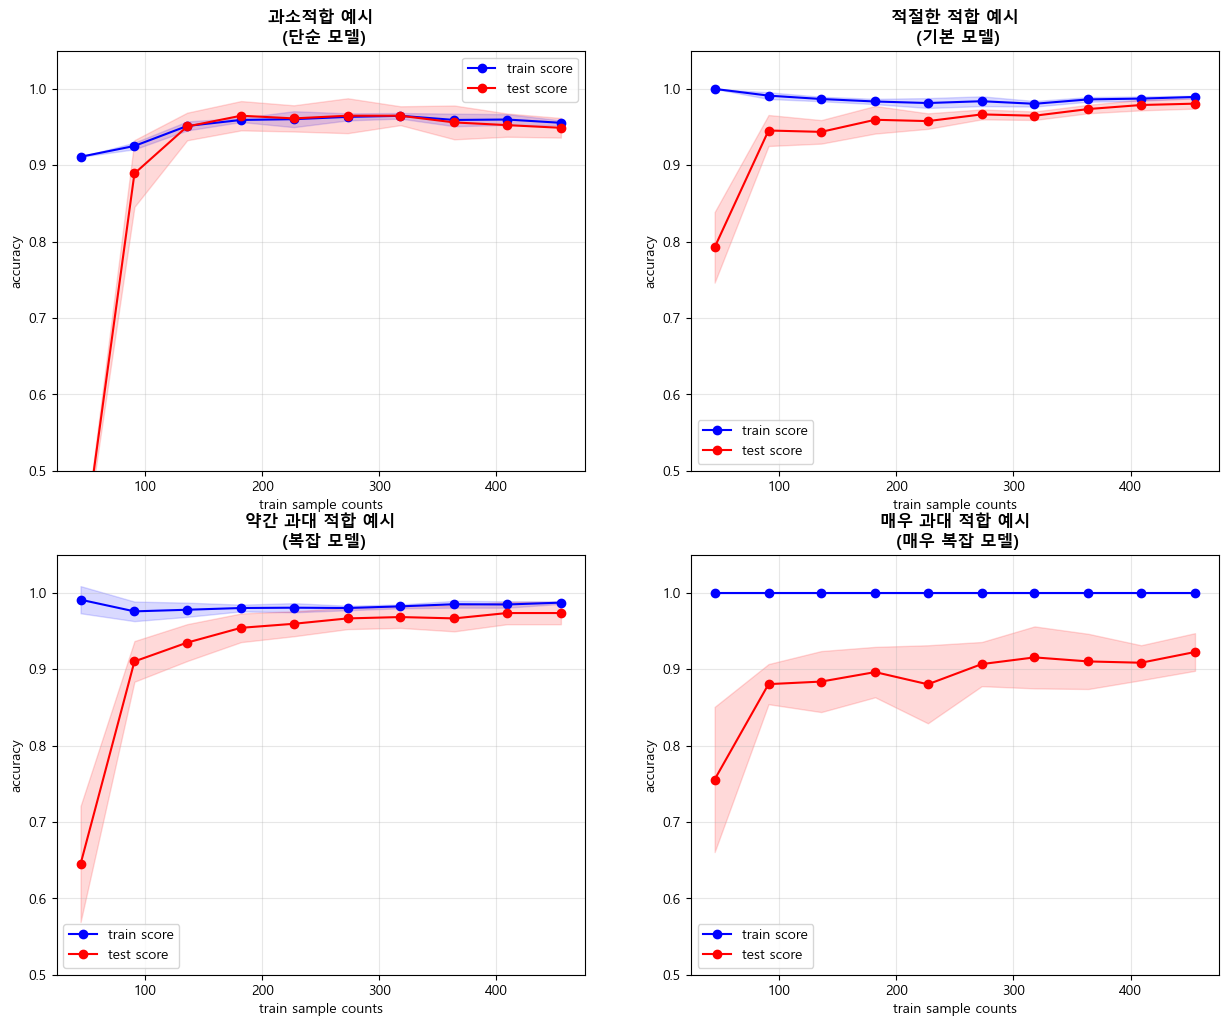

In [18]:
section4_learning_curves(X,y)

In [19]:
# 검증곡선으로 하이퍼 파라미터 분석
def section5_validation_curve(X,y):
    # 검증곡선
    # 최적 하이퍼파라미터 범위 확인
    # 과대/과소 적합 구간 확인

    fig, ax = plt.subplots(1,2, figsize=(15,5))
    # Logistic Regression C 파라미터
    print(f'Logistic Regression 정규화 파라미터 C')
    print('C 가 적을수록 강한 정규화')

    pipe = Pipeline ([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    param_range = np.logspace(-4,4,9)  #0.0001~10000
    train_scores, test_scores = validation_curve(
        pipe,X,y,
        param_name='clf__C',
        param_range=param_range,
        cv=5,
        scoring='accuracy',
        n_jobs= -1)
    
     # 평균과 표준편차
    train_mean = train_scores.mean(axis=1)
    train_std =  train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # 그래프 그리기 : semilogx - x축을 로그 스케일로 설정해서 선을 그리는 함수
    ax[0].semilogx(param_range, train_mean, label='train score', marker='o', color='blue')
    ax[0].fill_between(param_range, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

    ax[0].plot(param_range, test_mean, label='test score', marker='o', color='red')
    ax[0].fill_between(param_range, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

    ax[0].set_xlabel('Parameter C', fontsize=10)
    ax[0].set_ylabel('accuracy', fontsize=10)
    ax[0].set_title("Logistic Regression C", fontsize=12, fontweight='bold')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # 최적의 값
    best_idx = np.argmax(test_mean)
    best_c = param_range[best_idx]
    best_score = test_mean[best_idx]

    print(f'최적의 C: {best_c: .4f}')
    print(f'최고 검증 점수는 : {best_score: .4f}')

    # Decision Tree max_depth 파라미터 
    pipe = Pipeline ([
            ('scaler', StandardScaler()),
            ('clf', DecisionTreeClassifier())
        ])
    param_range = range(1,21)
    train_scores, test_scores = validation_curve(
        pipe,X,y,
        param_name='clf__max_depth',
        param_range=param_range,
        cv=5,
        scoring='accuracy',
        n_jobs= -1)

    # 평균과 표준편차
    train_mean = train_scores.mean(axis=1)
    train_std =  train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # 그래프 그리기 : semilogx - x축을 로그 스케일로 설정해서 선을 그리는 함수
    ax[1].semilogx(param_range, train_mean, label='train score', marker='o', color='blue')
    ax[1].fill_between(param_range, train_mean - train_std, train_mean+train_std, alpha=0.15, color='blue')

    ax[1].plot(param_range, test_mean, label='test score', marker='o', color='red')
    ax[1].fill_between(param_range, test_mean - test_std, test_mean+test_std, alpha=0.15, color='red')

    ax[1].set_xlabel('Parameter max_depth', fontsize=10)
    ax[1].set_ylabel('accuracy', fontsize=10)
    ax[1].set_title("Decision Tree max_depth", fontsize=12, fontweight='bold')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    
    # 최적의 값
    best_idx_2 = np.argmax(test_mean)
    best_c_2 = param_range[best_idx_2]
    best_score_2 = test_mean[best_idx_2]
    
    print('==================================')
    print(f'최적의 max_depth: {best_c_2: .4f}')
    print(f'최고 검증 점수는 : {best_score_2: .4f}')

Logistic Regression 정규화 파라미터 C
C 가 적을수록 강한 정규화
최적의 C:  1.0000
최고 검증 점수는 :  0.9807


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


최적의 max_depth:  2.0000
최고 검증 점수는 :  0.9280


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

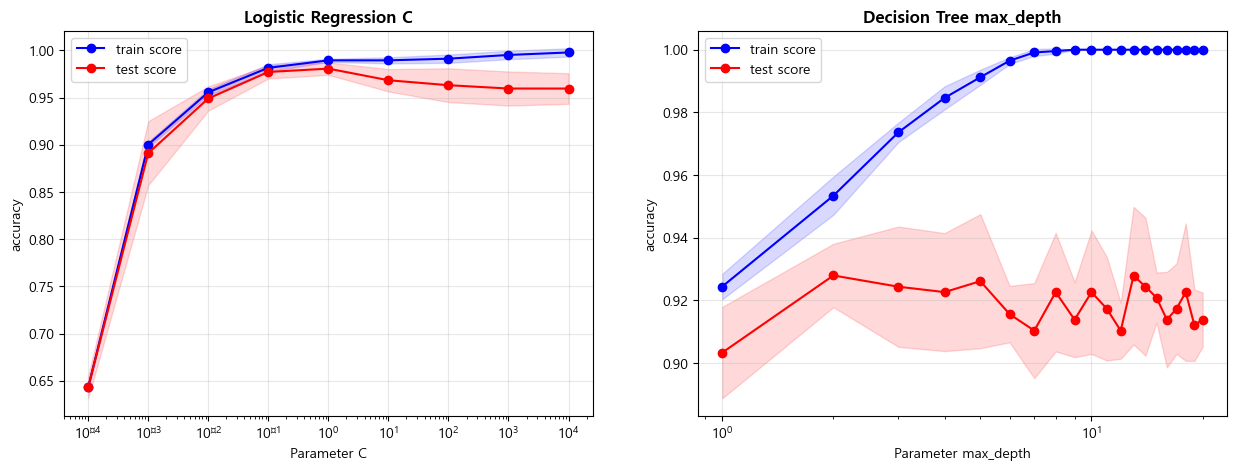

In [20]:
section5_validation_curve(X,y)